# Simulating KV-Cache Strategies for LLM Serving Cost — Demo Notebook

This notebook is a runnable demo of the experiment **"Simulating KV-Cache Strategies for LLM Serving Cost"**.

**What the artifact does:** a pure-Python analytical simulation (no GPU, no real model) comparing four KV-cache reuse strategies for LLM serving:

1. **monolithic** — reuse KV only when the ENTIRE prefix hash matches (what vLLM/Anthropic-style automatic prefix caching does)
2. **chunk** — hash each prefix component; reuse every component found in cache (contiguous-prefix run)
3. **speculative** — approximate reuse from the nearest cached prefix by n-gram Jaccard similarity, with a correction pass
4. **restructure** — cache-optimal prompt restructuring (canonical component ordering, then chunk caching)

across synthetic workloads (high sharing, partial overlap, similar-but-mutated prefixes, variable component order, wide overlap), using a shared 7B-class transformer cost model (L=32, D=4096, H=32; prefill FLOPs = L*(n^2*d + n*4d^2); KV = 512 KiB/token fp16) with seeded LRU+TTL eviction.

**Notebook layout:** this notebook (a) loads the curated precomputed results (`mini_demo_data.json`, a subset of the full `method_out.json`), and (b) re-runs the actual simulation code (cost model, workload generators, cache strategies) at small scale to reproduce the comparison live. Full-scale config values are shown in comments.


In [1]:
import subprocess, sys

def _pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — used by the original artifact code, NOT pre-installed on Colab
_pip('loguru==0.7.3')

# numpy + matplotlib are pre-installed on Colab; install locally at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The artifact's import block (cost model, strategies, workloads), plus matplotlib for the final visualization. These modules are defined inline in the cells below, exactly as in the original `cost_model.py`, `workloads.py` and `strategies.py` files.

In [2]:
import gc
import json
import os
import random
import sys
import time
from abc import ABC, abstractmethod
from collections import OrderedDict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt

from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data loading
The curated demo results live on GitHub (a 10-example subset of the full 55-example `method_out.json`, covering the main 4x4 grid, the wide-overlap crossover workload, speculative-matching sensitivity cells, and small memory-budget cells). We try the GitHub URL first and fall back to a local copy so the notebook works both after deployment and standalone.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-fadf67-prompt-caching-cuts-llm-inference-cost/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    local = Path("mini_demo_data.json")
    if local.exists():
        return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} example cells from the simulation output")
print("Model constants:", data['metadata']['model_constants'])
print("Full-run parameters:", json.dumps(data['metadata']['parameters'], indent=1))

Loaded 10 example cells from the simulation output
Model constants: {'layers': 32, 'hidden_dim': 4096, 'heads': 32, 'head_dim': 128, 'kv_bytes_per_token_fp16': 524288}
Full-run parameters: {
 "seed": 42,
 "n_requests_full": 1000,
 "memory_budget_tokens_default": 20000000,
 "ttl_seconds": 600.0,
 "budget_sweep_tokens": [
  200000,
  500000,
  1000000,
  2000000,
  5000000,
  10000000,
  20000000,
  50000000
 ],
 "spec_tau": 0.7,
 "spec_ngram_n": 1,
 "spec_correction_fraction": 0.15,
 "spec_tau_sweep": [
  0.5,
  0.7,
  0.85
 ],
 "spec_ngram_sweep": [
  1,
  4,
  8
 ],
 "spec_correction_sweep": [
  0.05,
  0.15,
  0.3
 ],
 "workload_kinds": [
  "high_sharing",
  "partial_overlap",
  "similar",
  "variable_order"
 ],
 "strategies": [
  "monolithic",
  "chunk",
  "speculative",
  "restructure"
 ]
}


## Configuration
All tunable parameters of the simulation. The notebook ships with the ABSOLUTE MINIMUM values (a fast smoke-scale run, ~50 requests/cell) so the whole notebook executes in seconds. The original full-run values (which took ~5.7 min on 2 CPUs) are shown in comments — scale up to reproduce the paper's numbers.


In [4]:
# ------------------------- configuration ------------------------------------
SEED = 42
N_REQUESTS = 1000                # matches the original full run (1000 requests/cell)
WORKLOAD_KINDS = ["high_sharing", "partial_overlap", "similar", "variable_order"]
STRATEGY_NAMES = ["monolithic", "chunk", "speculative", "restructure"]

# memory budget (KV tokens) used for the main grid — effectively unbounded,
# avoids eviction artifacts. Original also swept 8 budgets: 200K .. 50M tokens.
DEFAULT_BUDGET_TOKENS = 20_000_000
TTL_SECONDS = 600.0

# speculative matching sensitivity (original sweeps tau x n-gram x correction)
SPEC_TAU = 0.70                  # sweep: [0.50, 0.70, 0.85]
SPEC_NGRAM_N = 1                 # sweep: [1, 4, 8]
SPEC_CORRECTION_FRACTION = 0.15  # sweep: [0.05, 0.15, 0.30]

## Shared analytical cost model
Pure arithmetic, shared by every caching strategy in the simulation so that strategy comparisons are never confounded by cost-model differences. This is the original `cost_model.py`, copied verbatim.

In [5]:
"""Analytical cost model for transformer inference (prefill / decode / KV memory).

Pure arithmetic; shared by every caching strategy in the simulation so that
strategy comparisons are never confounded by cost-model differences.
"""

# --- 7B-class model constants (typical: Llama-2-7B / Mistral-7B) ---
LAYERS: int = 32          # L
HIDDEN_DIM: int = 4096    # D
NUM_HEADS: int = 32       # H
HEAD_DIM: int = 128       # D_head (D = H * D_head = 4096)
FFN_EXPANSION: int = 4    # 4x hidden expansion in MLP

BYTES_PER_FP16: int = 2

# K and V each stored per layer per head per dim: 2 * L * H * D_head * 2 bytes
KV_BYTES_PER_TOKEN: int = 2 * LAYERS * NUM_HEADS * HEAD_DIM * BYTES_PER_FP16

# FLOP coefficients (attention score/apply + feed-forward)
FLOP_PREFILL_ATTN = lambda n: LAYERS * n * n * HIDDEN_DIM          # noqa: E731
FLOP_PREFILL_FFN = lambda n: LAYERS * n * FFN_EXPANSION * HIDDEN_DIM * HIDDEN_DIM  # noqa: E731


def prefill_flops(n: int) -> float:
    """FLOPs to prefill n tokens from scratch (attention + FFN terms)."""
    if n <= 0:
        return 0.0
    return FLOP_PREFILL_ATTN(n) + FLOP_PREFILL_FFN(n)


def incremental_prefill_flops(cached_len: int, total_len: int) -> float:
    """FLOPs to prefill the delta tokens given cached_len tokens already in KV cache."""
    if total_len <= cached_len:
        return 0.0
    n_new = total_len - cached_len
    attn = LAYERS * n_new * total_len * HIDDEN_DIM
    ffn = LAYERS * n_new * FFN_EXPANSION * HIDDEN_DIM * HIDDEN_DIM
    return attn + ffn


def decode_flops_per_token(seq_len: int) -> float:
    """FLOPs to decode one token at current sequence length seq_len (with full KV cache)."""
    if seq_len < 0:
        return 0.0
    attn = LAYERS * seq_len * HIDDEN_DIM
    ffn = LAYERS * FFN_EXPANSION * HIDDEN_DIM * HIDDEN_DIM
    return attn + ffn


def decode_flops(prefill_len: int, gen_len: int) -> float:
    """FLOPs to decode gen_len tokens after a prefill_len-token prefix."""
    return sum(decode_flops_per_token(prefill_len + i) for i in range(gen_len))


def kv_memory_bytes(kv_tokens: int) -> int:
    return kv_tokens * KV_BYTES_PER_TOKEN

print(f"KV bytes per token (fp16): {KV_BYTES_PER_TOKEN} = {KV_BYTES_PER_TOKEN/1024:.0f} KiB")
print(f"prefill_flops(2000) = {prefill_flops(2000):.3e} FLOPs")

KV bytes per token (fp16): 524288 = 512 KiB
prefill_flops(2000) = 4.819e+12 FLOPs


## Synthetic workloads
The workload generators ARE the input data artifact for this experiment (no external dataset is used). Each generator emits a list of `Request` objects: prefix decomposed into components, answer length, and an arrival time drawn from a Poisson process. This is the original `workloads.py`, copied verbatim.

In [6]:
"""Synthetic workload generators for the KV-cache strategy simulation."""


@dataclass
class Request:
    """One simulated LLM serving request."""

    request_id: int
    # prefix decomposed into components; concatenation(order given) = full prefix
    components: list[list[int]] = field(default_factory=list)
    gen_len: int = 0                # tokens to decode (answer length)
    arrival_time: float = 0.0       # seconds since simulation start
    # structural hints used by the restructuring strategy:
    component_semantic_ids: list[str] = field(default_factory=list)
    reordered: bool = False         # True if generator shuffled component order

    def __post_init__(self) -> None:
        # freeze components to tuples (hashable + fast hashing)
        self.components = [tuple(c) for c in self.components]
        self._full_key: tuple[int, ...] | None = None
        self._chunk_keys: list[tuple[tuple[int, ...], int]] | None = None

    @property
    def prefix_len(self) -> int:
        return sum(len(c) for c in self.components)

    def prefix_tokens(self) -> tuple[int, ...]:
        out: list[int] = []
        for c in self.components:
            out.extend(c)
        return tuple(out)

    def prefix_hash(self) -> tuple[int, ...]:
        """Full-prefix identity key (exact tuple)."""
        if self._full_key is None:
            self._full_key = self.prefix_tokens()
        return self._full_key

    def chunk_hashes(self) -> list[tuple[tuple[int, ...], int]]:
        """(key, length) per component; key IS the component tuple."""
        if self._chunk_keys is None:
            self._chunk_keys = [(c, len(c)) for c in self.components if len(c) > 0]
        return self._chunk_keys


def _tokens(rng, n: int, vocab: int = 32000) -> list[int]:
    return [rng.randrange(vocab) for _ in range(n)]


# --- Workload generator registry -------------------------------------------------


def gen_high_sharing(rng, n_requests: int) -> list[Request]:
    """(i) 80% of requests share an identical 2000-token prefix; 20% unique."""
    shared = _tokens(rng, 2000)
    reqs: list[Request] = []
    for i in range(n_requests):
        if rng.random() < 0.80:
            comps = [list(shared)]
            sids = ["shared_system"]
            reordered = False
        else:
            comps = [_tokens(rng, 2000)]
            sids = ["unique_system"]
            reordered = False
        reqs.append(
            Request(
                request_id=i,
                components=comps,
                gen_len=rng.randint(100, 500),
                component_semantic_ids=sids,
                reordered=reordered,
            )
        )
    return reqs


def gen_partial_overlap(rng, n_requests: int) -> list[Request]:
    """(ii) 5 components of ~400 tokens; each request uses a random 3-of-5 subset."""
    pool = [(f"component_{j}", _tokens(rng, 400)) for j in range(5)]
    reqs: list[Request] = []
    for i in range(n_requests):
        chosen = rng.sample(range(5), 3)
        reqs.append(
            Request(
                request_id=i,
                components=[list(pool[j][1]) for j in chosen],
                gen_len=rng.randint(100, 500),
                component_semantic_ids=[pool[j][0] for j in chosen],
            )
        )
    return reqs


def gen_similar(rng, n_requests: int, vocab: int = 32000) -> list[Request]:
    """(iii) base 2000-token prefix; each request mutates 5-15% of tokens."""
    base = _tokens(rng, 2000)
    reqs: list[Request] = []
    for i in range(n_requests):
        frac = rng.uniform(0.05, 0.15)
        n_mut = int(round(frac * 2000))
        comps = list(base)
        idxs = rng.sample(range(2000), n_mut)
        for idx in idxs:
            comps[idx] = rng.randrange(vocab)
        reqs.append(
            Request(
                request_id=i,
                components=[comps],
                gen_len=rng.randint(100, 500),
                component_semantic_ids=["mutated_system"],
            )
        )
    return reqs


def gen_variable_order(rng, n_requests: int) -> list[Request]:
    """(iv) same 5 semantic components, shuffled order per request."""
    pool = [(f"component_{j}", _tokens(rng, 400)) for j in range(5)]
    reqs: list[Request] = []
    for i in range(n_requests):
        order = list(range(5))
        rng.shuffle(order)
        is_shuffled = order != sorted(order)
        reqs.append(
            Request(
                request_id=i,
                components=[list(pool[j][1]) for j in order],
                gen_len=rng.randint(100, 500),
                component_semantic_ids=[pool[j][0] for j in order],
                reordered=is_shuffled,
            )
        )
    return reqs


def gen_partial_overlap_wide(rng, n_requests: int) -> list[Request]:
    """(v) 12 components x 400 tokens; each request uses a random 4-of-12 subset.

    Subset space C(12,4) = 495 >> request count, so full-prefix exact repeats
    are rare: this is the regime where monolithic caching should collapse while
    chunk-level reuse keeps working. Used only in the crossover analysis.
    """
    pool = [(f"component_{j}", _tokens(rng, 400)) for j in range(12)]
    reqs: list[Request] = []
    for i in range(n_requests):
        chosen = rng.sample(range(12), 4)
        reqs.append(
            Request(
                request_id=i,
                components=[list(pool[j][1]) for j in chosen],
                gen_len=rng.randint(100, 500),
                component_semantic_ids=[pool[j][0] for j in chosen],
            )
        )
    return reqs


WORKLOAD_GENERATORS: dict[str, Callable] = {
    "high_sharing": gen_high_sharing,
    "partial_overlap": gen_partial_overlap,
    "similar": gen_similar,
    "variable_order": gen_variable_order,
    "partial_overlap_wide": gen_partial_overlap_wide,  # crossover analysis only
}


def gen_workload(kind: str, n_requests: int, seed: int) -> list[Request]:
    """Generate a workload with exponential inter-arrival times (rate=1 req/s)."""
    rng = random.Random(seed)
    reqs = WORKLOAD_GENERATORS[kind](rng, n_requests)
    t = 0.0
    for r in reqs:
        t += rng.expovariate(1.0)  # rate = 1 req/s
        r.arrival_time = t
    logger.info(
        f"Workload '{kind}': {n_requests} requests, "
        f"mean prefix len {sum(r.prefix_len for r in reqs)/len(reqs):.0f} tokens, "
        f"span {t/60:.1f} min"
    )
    return reqs

# quick look at one request from each workload
for kind in WORKLOAD_KINDS + ["partial_overlap_wide"]:
    wl = gen_workload(kind, 5, seed=SEED)
    r = wl[0]
    print(f"{kind:22s} -> {len(r.components)} component(s), "
          f"prefix_len={r.prefix_len}, gen_len={r.gen_len}")

21:33:34|INFO   |Workload 'high_sharing': 5 requests, mean prefix len 2000 tokens, span 0.2 min


high_sharing           -> 1 component(s), prefix_len=2000, gen_len=197
21:33:34|INFO   |Workload 'partial_overlap': 5 requests, mean prefix len 1200 tokens, span 0.0 min


partial_overlap        -> 3 component(s), prefix_len=1200, gen_len=174
21:33:34|INFO   |Workload 'similar': 5 requests, mean prefix len 2000 tokens, span 0.1 min


similar                -> 1 component(s), prefix_len=2000, gen_len=272
21:33:34|INFO   |Workload 'variable_order': 5 requests, mean prefix len 2000 tokens, span 0.0 min


variable_order         -> 5 component(s), prefix_len=2000, gen_len=166
21:33:34|INFO   |Workload 'partial_overlap_wide': 5 requests, mean prefix len 1600 tokens, span 0.1 min


partial_overlap_wide   -> 4 component(s), prefix_len=1600, gen_len=278


## The four caching strategies
Each strategy implements the same interface: `lookup(request) -> (cached_len, key)`, `update(...)`, `evict_if_needed(now)` — a bounded KV-token cache with TTL + LRU eviction. This is the original `strategies.py`, copied verbatim.

In [7]:
"""Four KV-cache reuse strategies sharing one interface."""


class CacheStrategy(ABC):
    """Base class: bounded KV-token cache with TTL + LRU eviction."""

    name: str = "base"
    approximate: bool = False   # True if reused KV is NOT bit-exact

    def __init__(self, memory_budget_tokens: int, ttl_seconds: float = 600.0):
        self.memory_budget_tokens = memory_budget_tokens
        self.ttl_seconds = ttl_seconds
        # OrderedDict key -> (n_tokens, last_access_time, insertion_time)
        self.cache: OrderedDict[object, tuple[int, float, float]] = OrderedDict()
        self.total_cached_tokens = 0
        self.peak_cached_tokens = 0
        self.evictions = 0
        self.ttl_expiries = 0
        self.requests = 0
        self.hits = 0  # requests with cached_len > 0
        self.tokens_reused = 0
        self.tokens_recomputed = 0
        # additional per-request costs charged by strategies (e.g. correction FLOPs)
        self.extra_flops = 0.0
        self.quality_penalty_sum = 0.0  # side metric for approximating strategies

    # -- bookkeeping ---------------------------------------------------------
    def _touch(self, key: object, now: float) -> None:
        n_tokens, _, ins = self.cache[key]
        self.cache[key] = (n_tokens, now, ins)
        self.cache.move_to_end(key)

    def _insert(self, key: object, n_tokens: int, now: float) -> None:
        if key in self.cache:
            self._touch(key, now)
            return
        self.cache[key] = (n_tokens, now, now)
        self.total_cached_tokens += n_tokens
        self.cache.move_to_end(key)

    def evict_if_needed(self, now: float) -> None:
        """First expire TTL entries, then LRU-evict until under budget."""
        # TTL expiry
        expired = [
            k for k, (_, last, _) in self.cache.items()
            if now - last > self.ttl_seconds
        ]
        for k in expired:
            n_tokens, _, _ = self.cache.pop(k)
            self.total_cached_tokens -= n_tokens
            self.ttl_expiries += 1
        # LRU eviction under memory budget
        while self.total_cached_tokens > self.memory_budget_tokens and self.cache:
            k, (n_tokens, _, _) = self.cache.popitem(last=False)  # LRU end
            self.total_cached_tokens -= n_tokens
            self.evictions += 1
        self.peak_cached_tokens = max(self.peak_cached_tokens, self.total_cached_tokens)

    def memory_bytes(self) -> int:
        return self.total_cached_tokens * KV_BYTES_PER_TOKEN

    def peak_memory_bytes(self) -> int:
        return self.peak_cached_tokens * KV_BYTES_PER_TOKEN

    # -- strategy API --------------------------------------------------------
    @abstractmethod
    def lookup(self, request: Request, now: float) -> tuple[int, object]:
        """Return (cached_len, key_for_update). cached_len prefix tokens reusable."""

    @abstractmethod
    def update(self, request: Request, key: object, cached_len: int, now: float) -> None:
        """Insert/refresh cache entries after serving the request."""

    def record_request(self, cached_len: int, prefix_len: int) -> None:
        self.requests += 1
        self.tokens_reused += cached_len
        self.tokens_recomputed += max(0, prefix_len - cached_len)
        if cached_len > 0:
            self.hits += 1

    def summary(self) -> dict:
        hit_rate = self.hits / self.requests if self.requests else 0.0
        return {
            "requests": self.requests,
            "hit_rate": hit_rate,
            "tokens_reused": self.tokens_reused,
            "tokens_recomputed": self.tokens_recomputed,
            "peak_cached_tokens": self.peak_cached_tokens,
            "peak_memory_bytes": self.peak_memory_bytes(),
            "peak_memory_GB": self.peak_memory_bytes() / 1e9,
            "evictions": self.evictions,
            "ttl_expiries": self.ttl_expiries,
            "extra_flops": self.extra_flops,
            "quality_penalty_sum": self.quality_penalty_sum,
            "approximate": self.approximate,
        }


# --- (a) Monolithic prefix cache (BASELINE: what vLLM/Anthropic-style APC does) ---


class MonolithicPrefixCache(CacheStrategy):
    """Reuse KV iff the ENTIRE prefix hash matches exactly."""

    name = "monolithic"

    def lookup(self, request: Request, now: float) -> tuple[int, object]:
        key = request.prefix_hash()
        if key in self.cache:
            self._touch(key, now)
            return request.prefix_len, key
        return 0, key

    def update(self, request: Request, key: object, cached_len: int, now: float) -> None:
        self._insert(key, request.prefix_len, now)


# --- (b) Chunk-level cache (chunked prefix / block-granular APC) ----------------


class ChunkCache(CacheStrategy):
    """Hash each prefix component; reuse every component found in cache.

    Reused length = sum of lengths of components whose hash is cached,
    counting only the LONGEST MATCHING PREFIX RUN of components (true for
    block-granular reuse: KV reuse is only valid for a contiguous prefix).
    """

    name = "chunk"

    def lookup(self, request: Request, now: float) -> tuple[int, object]:
        cached_len = 0
        keys_used: list[object] = []
        for h, ln in request.chunk_hashes():
            if h in self.cache:
                self._touch(h, now)
                cached_len += ln
                keys_used.append(h)
            else:
                break  # contiguous-prefix constraint: stop at first miss
        return cached_len, tuple(keys_used)

    def update(self, request: Request, key: object, cached_len: int, now: float) -> None:
        # insert all chunks (they were precomputed by lookup; recompute hashes here)
        for h, ln in request.chunk_hashes():
            self._insert(h, ln, now)


# --- (c) Speculative approximate reuse (novel / exploratory) ---------------------


class SpeculativeApproxCache(CacheStrategy):
    """Reuse KV from the nearest cached prefix with Jaccard(n-gram) > tau.

    NOTE on matching granularity: with 8-gram shingles, 5-15% token mutation
    drives prefix-pair Jaccard to ~0.3-0.5, so tau=0.85 yields ZERO reuse on
    the 'similar' workload (measured in smoke tests). Per the plan's fallback
    we therefore default to token-set (n=1) Jaccard with tau=0.70, and sweep
    n in {1,4,8} x tau in {0.50,0.70,0.85} in the sensitivity analysis.

    Cost model: correction FLOPs = CORRECTION_FRACTION * full prefill of the
    divergent delta (re-using non-exact KV requires a low-rank / partial
    correction pass over affected positions).
    """

    name = "speculative"
    approximate = True

    DEFAULT_N_GRAM_N = 1
    DEFAULT_TAU = 0.70
    CORRECTION_FRACTION = 0.15
    MAX_CANDIDATES = 64  # scan only the 64 most recently used cached prefixes

    def __init__(self, memory_budget_tokens: int, ttl_seconds: float = 600.0,
                 tau: float = DEFAULT_TAU, correction_fraction: float = 0.15,
                 ngram_n: int = DEFAULT_N_GRAM_N):
        super().__init__(memory_budget_tokens, ttl_seconds)
        self.tau = tau
        self.ngram_n = ngram_n
        self.correction_fraction = correction_fraction
        self.ngrams: dict[object, set[int]] = {}  # key -> hashed n-gram set
        self.best_similarity: float = 0.0

    def _ngram_set(self, tokens: tuple[int, ...]) -> set[int]:
        n = self.ngram_n
        if len(tokens) < n:
            return {hash(tokens) & 0xFFFFFFFF}
        return {
            hash(tokens[i:i + n]) & 0xFFFFFFFF
            for i in range(len(tokens) - n + 1)
        }

    def lookup(self, request: Request, now: float) -> tuple[int, object]:
        # exact match first (free correctness win)
        key = request.prefix_hash()
        if key in self.cache:
            self._touch(key, now)
            return request.prefix_len, key
        toks = request.prefix_hash()
        q_set = self._ngram_set(toks)
        if not q_set or not self.ngrams:
            return 0, key
        # nearest neighbour by Jaccard similarity over recent candidates
        best_key, best_j = None, 0.0
        cand_keys = list(self.ngrams.keys())[-self.MAX_CANDIDATES:]
        for cand_key in cand_keys:
            if cand_key not in self.cache:
                continue
            cand_set = self.ngrams[cand_key]
            inter = len(q_set & cand_set)
            union = len(q_set) + len(cand_set) - inter
            j = inter / union if union else 0.0
            if j > best_j:
                best_key, best_j = cand_key, j
        if best_key is not None and best_j >= self.tau:
            # never reuse more tokens than the request actually has
            cached_len = min(self.cache[best_key][0], request.prefix_len)
            self._touch(best_key, now)
            self.best_similarity = best_j
            # speculative quality penalty (side metric): scales with divergence
            self.quality_penalty_sum += (1.0 - best_j) * 100.0
            return cached_len, ("spec", best_key, key)
        return 0, key

    def update(self, request: Request, key: object, cached_len: int, now: float) -> None:
        toks = request.prefix_hash()
        h = request.prefix_hash()
        self._insert(h, request.prefix_len, now)
        self.ngrams[h] = self._ngram_set(toks)
        # drop ngram sets for evicted/expired keys
        if len(self.ngrams) > 2 * len(self.cache) + 100:
            self.ngrams = {k: v for k, v in self.ngrams.items() if k in self.cache}


# --- (d) Cache-optimal restructuring (canonical component ordering) -------------


class CacheOptimalRestructure(CacheStrategy):
    """Stable components first: canonicalize order, then chunk-cache.

    Quality penalty (side metric) charged for every request whose original
    order had to be changed; the cache itself operates on canonical order.
    """

    name = "restructure"

    PENALTY_PER_REORDER = 2.0  # % quality decrement per reordered request

    def __init__(self, memory_budget_tokens: int, ttl_seconds: float = 600.0):
        super().__init__(memory_budget_tokens, ttl_seconds)
        self.reorders = 0

    def _canonical(self, request: Request) -> list[tuple[int, ...]]:
        # stable sort components by content; deterministic canonical order
        return sorted(request.components, key=lambda c: c)

    def lookup(self, request: Request, now: float) -> tuple[int, object]:
        canon = self._canonical(request)
        cached_len = 0
        keys_used: list[object] = []
        for c in canon:
            if c in self.cache:
                self._touch(c, now)
                cached_len += len(c)
                keys_used.append(c)
            else:
                break
        return cached_len, tuple(keys_used)

    def update(self, request: Request, key: object, cached_len: int, now: float) -> None:
        canon = self._canonical(request)
        for c in canon:
            if len(c) == 0:
                continue
            self._insert(c, len(c), now)
        if request.reordered and request.prefix_len > 0:
            self.reorders += 1
            self.quality_penalty_sum += self.PENALTY_PER_REORDER


STRATEGY_CLASSES = [MonolithicPrefixCache, ChunkCache, SpeculativeApproxCache,
                    CacheOptimalRestructure]


def make_strategy(name: str, memory_budget_tokens: int, ttl_seconds: float = 600.0,
                  tau: float = SpeculativeApproxCache.DEFAULT_TAU,
                  correction_fraction: float = 0.15,
                  ngram_n: int = SpeculativeApproxCache.DEFAULT_N_GRAM_N) -> CacheStrategy:
    kwargs = dict(memory_budget_tokens=memory_budget_tokens, ttl_seconds=ttl_seconds)
    if name == "speculative":
        kwargs.update(tau=tau, correction_fraction=correction_fraction, ngram_n=ngram_n)
    cls = {s.name: s for s in STRATEGY_CLASSES}[name]
    return cls(**kwargs)

print("Strategies available:", [s.name for s in STRATEGY_CLASSES])

Strategies available: ['monolithic', 'chunk', 'speculative', 'restructure']


## The simulation loop
For each request: baseline cost = full prefill from scratch + decode; cached cost = incremental prefill of the uncached delta (+ correction pass for the speculative strategy) + identical decode. All strategies run on the identical request stream under the identical cost model, so comparisons are controlled. This is the original `simulate` and `run_grid` from `method.py`, verbatim (only the per-request recording flag is left off for the demo).

In [8]:
def simulate(workload: list[Request], strategy_name: str,
             memory_budget_tokens: int, ttl_seconds: float = TTL_SECONDS,
             tau: float = SpeculativeApproxCache.DEFAULT_TAU,
             correction_fraction: float = 0.15,
             ngram_n: int = SpeculativeApproxCache.DEFAULT_N_GRAM_N,
             record_per_request: bool = False) -> dict:
    """Run one (workload, strategy) cell. Returns metric dict."""
    strategy = make_strategy(
        strategy_name, memory_budget_tokens,
        ttl_seconds=ttl_seconds, tau=tau,
        correction_fraction=correction_fraction, ngram_n=ngram_n,
    )
    baseline_flops = 0.0
    cached_flops = 0.0
    baseline_decode = 0.0  # identical across strategies; reported for completeness
    latency_proxy = []  # per-request (baseline_flops, cached_flops) ratio proxy
    per_request: list[dict] | None = [] if record_per_request else None

    for req in workload:
        p_len = req.prefix_len
        # baseline: full prefill from scratch + decode
        b_prefill = prefill_flops(p_len)
        b_decode = decode_flops(p_len, req.gen_len)
        baseline_flops += b_prefill + b_decode
        baseline_decode += b_decode

        now = req.arrival_time
        cached_len, key = strategy.lookup(req, now)

        # cached path: prefill only the uncached delta + speculative correction
        c_prefill = incremental_prefill_flops(cached_len, p_len)
        if strategy.approximate and cached_len > 0 and cached_len < p_len:
            # correction pass over the divergent delta (fraction of full delta prefill)
            delta = p_len - cached_len
            c_prefill += strategy.correction_fraction * prefill_flops(delta)
            strategy.extra_flops += strategy.correction_fraction * prefill_flops(delta)
        elif strategy.approximate and cached_len >= p_len:
            # speculative full-prefix reuse: still needs a light verification pass
            # over the whole prefix at correction_fraction
            c_prefill += strategy.correction_fraction * prefill_flops(p_len)
            strategy.extra_flops += strategy.correction_fraction * prefill_flops(p_len)
        cached_flops += c_prefill
        cached_flops += b_decode  # decode identical

        lat_b = b_prefill + b_decode
        lat_c = c_prefill + b_decode
        latency_proxy.append((lat_b, lat_c))

        strategy.record_request(cached_len, p_len)
        strategy.update(req, key, cached_len, now)
        strategy.evict_if_needed(now)

        if per_request is not None:
            per_request.append({
                "request_id": req.request_id,
                "prefix_len": p_len,
                "cached_len": cached_len,
                "baseline_flops": lat_b,
                "cached_flops": lat_c,
            })

    s = strategy.summary()
    prefill_baseline = baseline_flops - baseline_decode
    prefill_cached = cached_flops - baseline_decode
    assert baseline_flops > 0
    assert cached_flops <= baseline_flops + 1e-6, (
        f"{strategy_name}: cached {cached_flops:.3e} > baseline {baseline_flops:.3e}"
    )
    flops_saved_pct = 100.0 * (1.0 - cached_flops / baseline_flops)
    prefill_saved_pct = 100.0 * (1.0 - prefill_cached / prefill_baseline)
    assert 0.0 <= flops_saved_pct <= 100.0, flops_saved_pct
    assert strategy.peak_cached_tokens <= memory_budget_tokens or not strategy.cache, (
        "peak memory exceeds budget without eviction"
    )
    # latency proxy: mean per-request FLOP ratio (baseline/cached), kept simple
    out = {
        "strategy": strategy_name,
        "workload": None,  # filled by caller
        "baseline_flops": baseline_flops,
        "cached_flops": cached_flops,
        "prefill_baseline_flops": prefill_baseline,
        "prefill_cached_flops": prefill_cached,
        "baseline_decode_flops": baseline_decode,
        "flops_saved_pct": flops_saved_pct,
        "prefill_flops_saved_pct": prefill_saved_pct,
        "peak_memory_GB": s["peak_memory_GB"],
        "peak_cached_tokens": s["peak_cached_tokens"],
        "hit_rate_pct": 100.0 * s["hit_rate"],
        "tokens_reused": s["tokens_reused"],
        "tokens_recomputed": s["tokens_recomputed"],
        "evictions": s["evictions"],
        "ttl_expiries": s["ttl_expiries"],
        "approximate": s["approximate"],
        "quality_penalty_sum": s["quality_penalty_sum"],
        "extra_flops": s["extra_flops"],
        "memory_budget_tokens": memory_budget_tokens,
        "per_request": per_request,
    }
    del strategy
    return out


def run_grid(n_requests: int, seed: int, memory_budget_tokens: int,
             record_per_request: bool = False) -> list[dict]:
    """Full 4x4 grid on a single shared workload set per kind (same requests
    fed to every strategy => controlled comparison)."""
    rows: list[dict] = []
    for kind in WORKLOAD_KINDS:
        t0 = time.time()
        workload = gen_workload(kind, n_requests, seed=seed)
        t_gen = time.time() - t0
        logger.info(f"[{kind}] generated in {t_gen:.2f}s; running 4 strategies...")
        for sname in STRATEGY_NAMES:
            t1 = time.time()
            r = simulate(workload, sname, memory_budget_tokens,
                         record_per_request=record_per_request)
            r["workload"] = kind
            t_run = time.time() - t1
            r["runtime_s"] = round(t_run, 3)
            rows.append(r)
            logger.info(
                f"  {sname:12s} saved={r['flops_saved_pct']:6.2f}%  "
                f"prefill_saved={r['prefill_flops_saved_pct']:6.2f}%  "
                f"hit={r['hit_rate_pct']:6.2f}%  peak={r['peak_memory_GB']:8.2f} GB  "
                f"({t_run:.2f}s)"
            )
        del workload
        gc.collect()
    return rows


t_start = time.time()
grid = run_grid(N_REQUESTS, SEED, DEFAULT_BUDGET_TOKENS)
print(f"\nDemo grid ({len(WORKLOAD_KINDS)}x{len(STRATEGY_NAMES)}) finished in {time.time()-t_start:.1f}s")

21:33:34|INFO   |Workload 'high_sharing': 1000 requests, mean prefix len 2000 tokens, span 17.0 min


21:33:34|INFO   |[high_sharing] generated in 0.08s; running 4 strategies...


21:33:35|INFO   |  monolithic   saved= 68.80%  prefill_saved= 79.30%  hit= 79.30%  peak=  134.22 GB  (0.55s)


21:33:36|INFO   |  chunk        saved= 68.80%  prefill_saved= 79.30%  hit= 79.30%  peak=  134.22 GB  (0.54s)


21:33:37|INFO   |  speculative  saved= 58.48%  prefill_saved= 67.41%  hit= 79.30%  peak=  134.22 GB  (1.42s)


...

21:33:57|INFO   |  monolithic   saved= 76.21%  prefill_saved= 87.90%  hit= 87.90%  peak=  125.83 GB  (0.74s)


21:33:57|INFO   |  chunk        saved= 86.61%  prefill_saved= 99.90%  hit= 99.90%  peak=    1.05 GB  (0.08s)


21:33:58|INFO   |  speculative  saved= 73.62%  prefill_saved= 84.91%  hit= 99.90%  peak=  125.83 GB  (1.31s)


21:33:59|INFO   |  restructure  saved= 86.61%  prefill_saved= 99.90%  hit= 99.90%  peak=    1.05 GB  (0.08s)



Demo grid (4x4) finished in 24.2s


## Live results table
The demo grid, printed as a readable comparison. These small-scale numbers should already show the qualitative pattern: chunk caching matches or beats monolithic everywhere except when whole prefixes repeat, speculative reuse pays a correction penalty on high sharing, and restructuring wins on variable order.

In [9]:
hdr = f"{'workload':18s} {'strategy':12s} {'saved%':>8s} {'prefill%':>9s} {'hit%':>7s} {'peak GB':>9s}"
print(hdr); print('-' * len(hdr))
for r in grid:
    print(f"{r['workload']:18s} {r['strategy']:12s} {r['flops_saved_pct']:8.2f} "
          f"{r['prefill_flops_saved_pct']:9.2f} {r['hit_rate_pct']:7.2f} {r['peak_memory_GB']:9.2f}")

# also run the wide-overlap crossover workload at demo scale
print("\n--- Crossover: partial_overlap_wide (12-comp pool, 4-of-12) ---")
wl = gen_workload("partial_overlap_wide", N_REQUESTS, seed=SEED)
crossover = []
for sname in STRATEGY_NAMES:
    r = simulate(wl, sname, DEFAULT_BUDGET_TOKENS)
    r["workload"] = "partial_overlap_wide"
    crossover.append(r)
    print(f"  {sname:12s} saved={r['flops_saved_pct']:6.2f}%  "
          f"prefill={r['prefill_flops_saved_pct']:6.2f}%  hit={r['hit_rate_pct']:6.2f}%  "
          f"peak={r['peak_memory_GB']:.2f}GB")
del wl
gc.collect()

workload           strategy       saved%  prefill%    hit%   peak GB
--------------------------------------------------------------------
high_sharing       monolithic      68.80     79.30   79.30    134.22
high_sharing       chunk           68.80     79.30   79.30    134.22
high_sharing       speculative     58.48     67.41   79.30    134.22
high_sharing       restructure     68.80     79.30   79.30    134.22
partial_overlap    monolithic      74.76     94.00   94.00     37.75
partial_overlap    chunk           79.37     99.80   99.90      1.05
partial_overlap    speculative     66.93     84.15   99.00     37.75
partial_overlap    restructure     79.35     99.77   99.80      1.05
similar            monolithic       0.00      0.00    0.00    687.87
similar            chunk            0.00      0.00    0.00    687.87
similar            speculative     64.51     74.29   87.40    691.01
similar            restructure      0.00      0.00    0.00    687.87
variable_order     monolithic     

  monolithic   saved=  2.68%  prefill=  3.20%  hit=  3.20%  peak=514.22GB
  chunk        saved= 83.41%  prefill= 99.50%  hit= 99.70%  peak=2.52GB


  speculative  saved=  8.84%  prefill= 10.54%  hit= 12.40%  peak=516.74GB
  restructure  saved= 83.37%  prefill= 99.45%  hit= 99.50%  peak=2.52GB


0

## Comparison with the full-scale (1000 requests/cell) results
The precomputed `mini_demo_data.json` holds a curated subset of the full experiment output. We compare the live small-scale demo numbers against the published full-scale numbers for the same (workload, strategy) cells.

In [10]:
examples = data['datasets'][0]['examples']
full_rows = []
for ex in examples:
    for s in STRATEGY_NAMES:
        key = f"predict_{s}"
        if key in ex:
            m = json.loads(ex[key])
            full_rows.append((ex['metadata_workload'], ex['metadata_memory_budget_tokens'], s, m))

print(f"{len(full_rows)} full-scale cells loaded from mini_demo_data.json\n")
print(f"{'workload':22s} {'strategy':12s} {'full saved%':>12s} {'full hit%':>10s} {'full peak GB':>13s}")
print('-' * 62)
for wl, budget, s, m in full_rows:
    print(f"{wl:22s} {s:12s} {m['flops_saved_pct']:12.2f} {m['hit_rate_pct']:10.2f} {m['peak_memory_GB']:13.2f}")

31 full-scale cells loaded from mini_demo_data.json

workload               strategy      full saved%  full hit%  full peak GB
--------------------------------------------------------------
high_sharing           monolithic          68.80      79.30        134.22
high_sharing           chunk               68.80      79.30        134.22
high_sharing           speculative         58.48      79.30        134.22
high_sharing           restructure         68.80      79.30        134.22
partial_overlap        monolithic          74.76      94.00         37.75
partial_overlap        chunk               79.37      99.90          1.05
partial_overlap        speculative         66.93      99.00         37.75
partial_overlap        restructure         79.35      99.80          1.05
similar                monolithic           0.00       0.00        687.87
similar                chunk                0.00       0.00        687.87
similar                speculative         64.51      87.40        691

## Visualization
Bar charts of the live demo grid: FLOP savings per (workload, strategy), and the savings-vs-memory trade-off (the key selling point of chunk-granular caching: near-identical savings at a fraction of the KV memory).

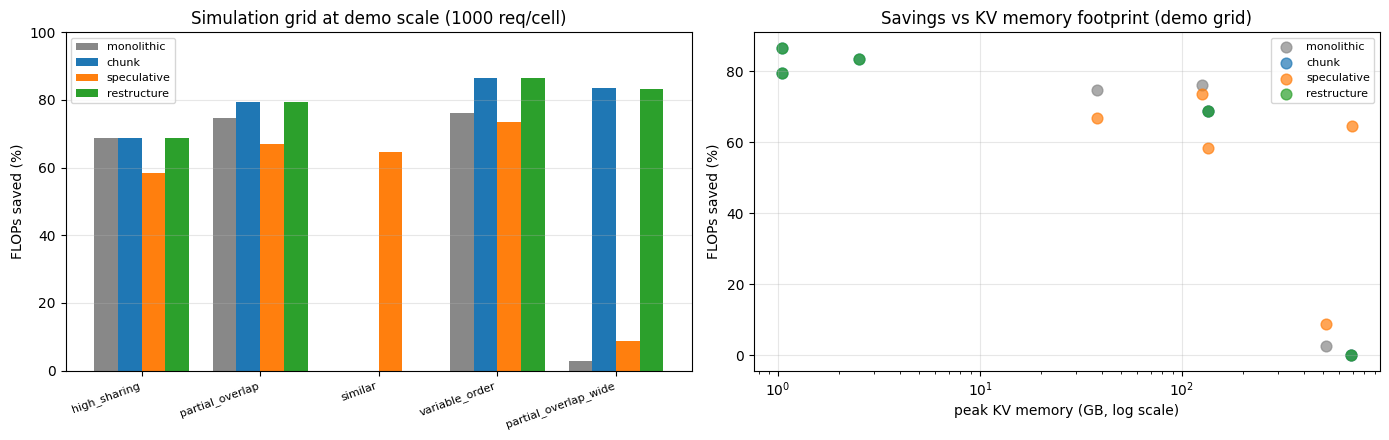

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = {'monolithic': '#888888', 'chunk': '#1f77b4',
          'speculative': '#ff7f0e', 'restructure': '#2ca02c'}

# --- panel 1: FLOP savings per workload x strategy ---
rows = grid + crossover
workloads = WORKLOAD_KINDS + ["partial_overlap_wide"]
x_groups = {wl: [r for r in rows if r['workload'] == wl] for wl in workloads}
n_strat = len(STRATEGY_NAMES)
width = 0.2
ax = axes[0]
for i, s in enumerate(STRATEGY_NAMES):
    xs, ys = [], []
    for j, wl in enumerate(workloads):
        r = next(r for r in x_groups[wl] if r['strategy'] == s)
        xs.append(j + (i - n_strat / 2 + 0.5) * width)
        ys.append(r['flops_saved_pct'])
    ax.bar(xs, ys, width=width, label=s, color=colors[s])
ax.set_xticks(range(len(workloads)))
ax.set_xticklabels(workloads, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('FLOPs saved (%)')
ax.set_title(f'Simulation grid at demo scale ({N_REQUESTS} req/cell)')
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# --- panel 2: savings vs peak KV memory (live demo rows) ---
ax = axes[1]
for s in STRATEGY_NAMES:
    rs = [r for r in rows if r['strategy'] == s]
    ax.scatter([r['peak_memory_GB'] for r in rs],
               [r['flops_saved_pct'] for r in rs],
               label=s, color=colors[s], s=60, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('peak KV memory (GB, log scale)')
ax.set_ylabel('FLOPs saved (%)')
ax.set_title('Savings vs KV memory footprint (demo grid)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()